## Предобученные Word2vec-признаки 

In [22]:
import sys
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
import nltk
import nltk.corpus
import nltk.tokenize
import string
from string import punctuation
import torch
import gensim
from gensim.models.word2vec import Word2Vec
import torch.nn as nn
import torch.nn.functional as F
import scipy
import pickle
import torch.utils.data as data_utils
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

ruscorpora_upos_cbow_300_20_2019

In [2]:
model = gensim.models.KeyedVectors.load_word2vec_format('C:\\Users\\Landi\\Downloads\\180\\model.bin', encoding='utf-8', unicode_errors='ignore', binary=True)
model.init_sims(replace=True)

C:\Users\Landi\AppData\Local\Temp\ipykernel_18336\1511196566.py:2: DeprecationWarning: Call to deprecated `init_sims` (Use fill_norms() instead. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  model.init_sims(replace=True)


In [3]:
words = list(model.key_to_index.keys())
words[:10]

['так_ADV',
 'быть_VERB',
 'мочь_VERB',
 'год_NOUN',
 'человек_NOUN',
 'xxxxxx_NUM',
 'сказать_VERB',
 'еще_ADV',
 'один_NUM',
 'говорить_VERB']

In [4]:
model.most_similar('работа_NOUN')

[('работа_PROPN', 0.6275458335876465),
 ('деятельность_NOUN', 0.5942718982696533),
 ('занятие_NOUN', 0.5689679980278015),
 ('работник_NOUN', 0.5591939091682434),
 ('подготовка_NOUN', 0.5507606267929077),
 ('работать_VERB', 0.540457010269165),
 ('проработка_NOUN', 0.5389595627784729),
 ('труд_NOUN', 0.5383162498474121),
 ('учеба_NOUN', 0.533196210861206),
 ('ремонтно_ADV', 0.5310532450675964)]

In [5]:
model.key_to_index['работа_NOUN']

51

In [6]:
model[model.key_to_index['работа_NOUN']]

array([-5.85179999e-02,  1.51592894e-02,  5.26082925e-02,  2.84647346e-02,
       -9.19876322e-02,  3.31219174e-02, -5.48914485e-02,  8.50201547e-02,
       -4.79608141e-02, -4.56790999e-02, -9.79803130e-03, -2.82755475e-02,
        2.62311511e-02,  4.88116108e-02, -9.27252602e-03,  3.13171744e-02,
        1.15742274e-01, -1.07745007e-02,  1.34846484e-02,  2.54330169e-02,
       -1.21560041e-02, -5.74568734e-02, -4.39964607e-02, -2.54943911e-02,
       -2.92804721e-03, -5.36553748e-03,  5.58856130e-03, -7.76704550e-02,
       -7.14043528e-02, -3.60808447e-02, -3.80626358e-02, -2.96954205e-03,
       -4.11674334e-03,  2.94200815e-02, -2.26382669e-02,  4.57425900e-02,
        8.05843994e-02, -6.46375716e-02,  4.37328219e-03, -3.19926478e-02,
        6.68301806e-02, -6.37132525e-02, -2.53209062e-02,  2.30549518e-02,
        6.25994205e-02,  6.14756420e-02,  2.49930043e-02, -1.55610614e-04,
        9.81186703e-02,  2.21989341e-02,  6.33945614e-02,  4.56209742e-02,
        6.32128539e-03,  

In [27]:
model.similarity('кошка_NOUN', 'собака_NOUN').item()

0.6829918622970581

In [8]:
model.similarity('кошка_NOUN', 'день_NOUN').item()

-0.028457799926400185

In [9]:
negative_file='C:\\Users\\Landi\\ИТМО\\2 сем\\NLP\\lab1\\negative.csv'
positive_file='C:\\Users\\Landi\\ИТМО\\2 сем\\NLP\\lab1\\positive.csv'

negative_df = pd.read_csv(negative_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'], nrows=10000)
positive_df = pd.read_csv(positive_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'], nrows=10000)

sentiment = pd.concat([negative_df, positive_df])[['ttext', 'ttype']]
sentiment.loc[(sentiment.ttype < 0), ('ttype')] = 0
sentiment

,ttext,ttype
0,на работе был полный пиддес :| и так каждое за...,0
1,"Коллеги сидят рубятся в Urban terror, а я из-з...",0
2,@elina_4post как говорят обещаного три года жд...,0
3,"Желаю хорошего полёта и удачной посадки,я буду...",0
4,"Обновил за каким-то лешим surf, теперь не рабо...",0
...,...,...
9995,"Все равно, я бы чувствовала себя лучше, если б...",1
9996,-Я пошла вешаться...-Что?! Что случилось?-Проб...,1
9997,"Идеальный перерыв с любимой Катюхой, пиано мас...",1
9998,Удахгүй дүн гарахаар мэдээлэл хийнээ :)) http:...,1


In [10]:
sys.path.append('C:\\Users\\Landi\\ИТМО\\2 сем\\NLP\\lab1')


предобработка и частеречная разметка

In [ ]:
import rus_preprocessing_udpipe as udpipe

# Функция для обработки одного текста
def process_with_udpipe(text):
    cleaned = udpipe.unify_sym(str(text).strip())
    tokens = udpipe.process(
        udpipe.process_pipeline,
        text=cleaned,
        keep_pos=True,
        keep_punct=False
    )
    return ' '.join(tokens)

sentiment['text_pos'] = sentiment['ttext'].apply(process_with_udpipe)

# список токенов
sentiment['X'] = sentiment['text_pos'].apply(lambda x: x.split())


sentiment.to_csv('sentiment_with_pos.csv', index=False, encoding='utf-8')
print(sentiment[['ttext', 'text_pos', 'ttype']].head())

                                               ttext  \
0  на работе был полный пиддес :| и так каждое за...   
1  Коллеги сидят рубятся в Urban terror, а я из-з...   
2  @elina_4post как говорят обещаного три года жд...   
3  Желаю хорошего полёта и удачной посадки,я буду...   
4  Обновил за каким-то лешим surf, теперь не рабо...   

                                            text_pos  ttype  
0  на_ADP работа_NOUN быть_AUX полный_ADJ пиддо_N...      0  
1  коллега_NOUN сидеть_VERB рубиться_VERB в_ADP u...      0  
2  @elina4post_X как_SCONJ говорить_VERB обещаный...      0  
3  желать_VERB хороший_ADJ полет_NOUN и_CCONJ уда...      0  
4  обновить_VERB за_ADP какой-то_ADJ лешимый_ADJ ...      0  


In [13]:
sentiment.head()

,ttext,ttype,text_pos,X
0,на работе был полный пиддес :| и так каждое за...,0,на_ADP работа_NOUN быть_AUX полный_ADJ пиддо_N...,"[на_ADP, работа_NOUN, быть_AUX, полный_ADJ, пи..."
1,"Коллеги сидят рубятся в Urban terror, а я из-з...",0,коллега_NOUN сидеть_VERB рубиться_VERB в_ADP u...,"[коллега_NOUN, сидеть_VERB, рубиться_VERB, в_A..."
2,@elina_4post как говорят обещаного три года жд...,0,@elina4post_X как_SCONJ говорить_VERB обещаный...,"[@elina4post_X, как_SCONJ, говорить_VERB, обещ..."
3,"Желаю хорошего полёта и удачной посадки,я буду...",0,желать_VERB хороший_ADJ полет_NOUN и_CCONJ уда...,"[желать_VERB, хороший_ADJ, полет_NOUN, и_CCONJ..."
4,"Обновил за каким-то лешим surf, теперь не рабо...",0,обновить_VERB за_ADP какой-то_ADJ лешимый_ADJ ...,"[обновить_VERB, за_ADP, какой-то_ADJ, лешимый_..."


In [14]:
def word_averaging(model, words):
    all_words, mean = set(), []

    for word in words:
        if word in model.key_to_index.keys():
            mean.append(model[model.key_to_index[word]])
            all_words.add(model.key_to_index[word])

    if not mean:
        #logging.warning("cannot compute similarity with no input %s", words)
        # FIXME: remove these examples in pre-processing
        return np.zeros(model.vector_size)

    mean = gensim.matutils.unitvec(np.array(mean).mean(axis=0)).astype(np.float32)
    return mean

In [15]:
def  word_averaging_list(model, text_list):
    return np.vstack([word_averaging(model, comment_text) for comment_text in text_list ])

In [19]:
X=sentiment['X']
y=sentiment['ttype'].values.tolist()

In [20]:
X = word_averaging_list(model, X)
X.shape

(20000, 300)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [23]:
# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
def plot_confusion(model_name, y_pred, y_test):
   
    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    
    # Подписи классов
    labels = ["Отрицательный", "Положительный"]
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=labels,
                yticklabels=labels)
    plt.xlabel("Предсказанные метки")
    plt.ylabel("Истинные метки")
    plt.title(f"Матрица ошибок ({model_name})")
    plt.show()

In [25]:
# Создание и обучение модели
svc = SVC(random_state=42, kernel='rbf')
svc.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False



Classification report:

               precision    recall  f1-score   support

           0       0.69      0.70      0.70      2990
           1       0.70      0.69      0.69      3010

    accuracy                           0.69      6000
   macro avg       0.69      0.69      0.69      6000
weighted avg       0.69      0.69      0.69      6000



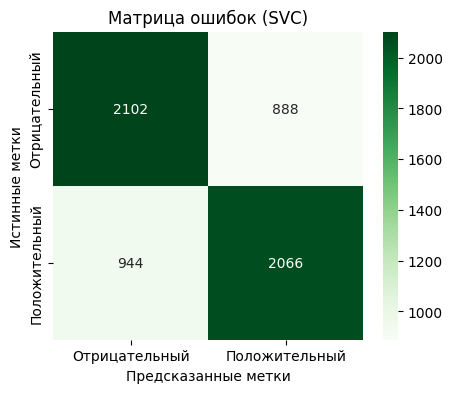

In [26]:
# Предсказания
y_pred_svc = svc.predict(X_test_scaled)

print("\nClassification report:\n\n", classification_report(y_test, y_pred_svc))
plot_confusion("SVC", y_pred_svc, y_test)